# KNN y Análisis de Componentes Principales (PCA)

Este notebook organiza y compara el rendimiento del modelo K-Nearest Neighbors (KNN) con y sin PCA (5 componentes).

**Estructura del Documento:**
1. **PCA (5 Componentes)**
   - Loadings (Gráfica de barras)
   - Biplot (Observaciones y variables)
   - Scree Plot
2. **Evaluación de Rendimiento**
   - Comparación base: Variables escaladas vs. sin escalar.
   - Evolución de métricas (`Accuracy`, `Precision`, `Recall`, `F1-Score`) iterando sobre `K` (Sin PCA vs Con PCA).
3. **Matrices de Confusión**
   - Resultados detallados de falsos positivos y negativos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [5]:
# Carga y Limpieza de datos
df = pd.read_csv('Cancer_Data.csv')
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Limpiar nombres de columna: eliminar espacios y comillas dobles
df.columns = df.columns.str.strip().str.replace('"', '')

# Limpiar valores de la columna 'diagnosis' y codificarlos (M: 1, B: 0)
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado general de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Datos cargados y escalados con éxito.")

Datos cargados y escalados con éxito.


---
## 1. PCA (5 Componentes)

In [6]:
# Aplicación de PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 1.1 Loadings (Gráfica de Barras)
Analizamos qué variables originales tienen mayor peso o aporte en la formación de la primera (PC1) y segunda (PC2) componente principal.

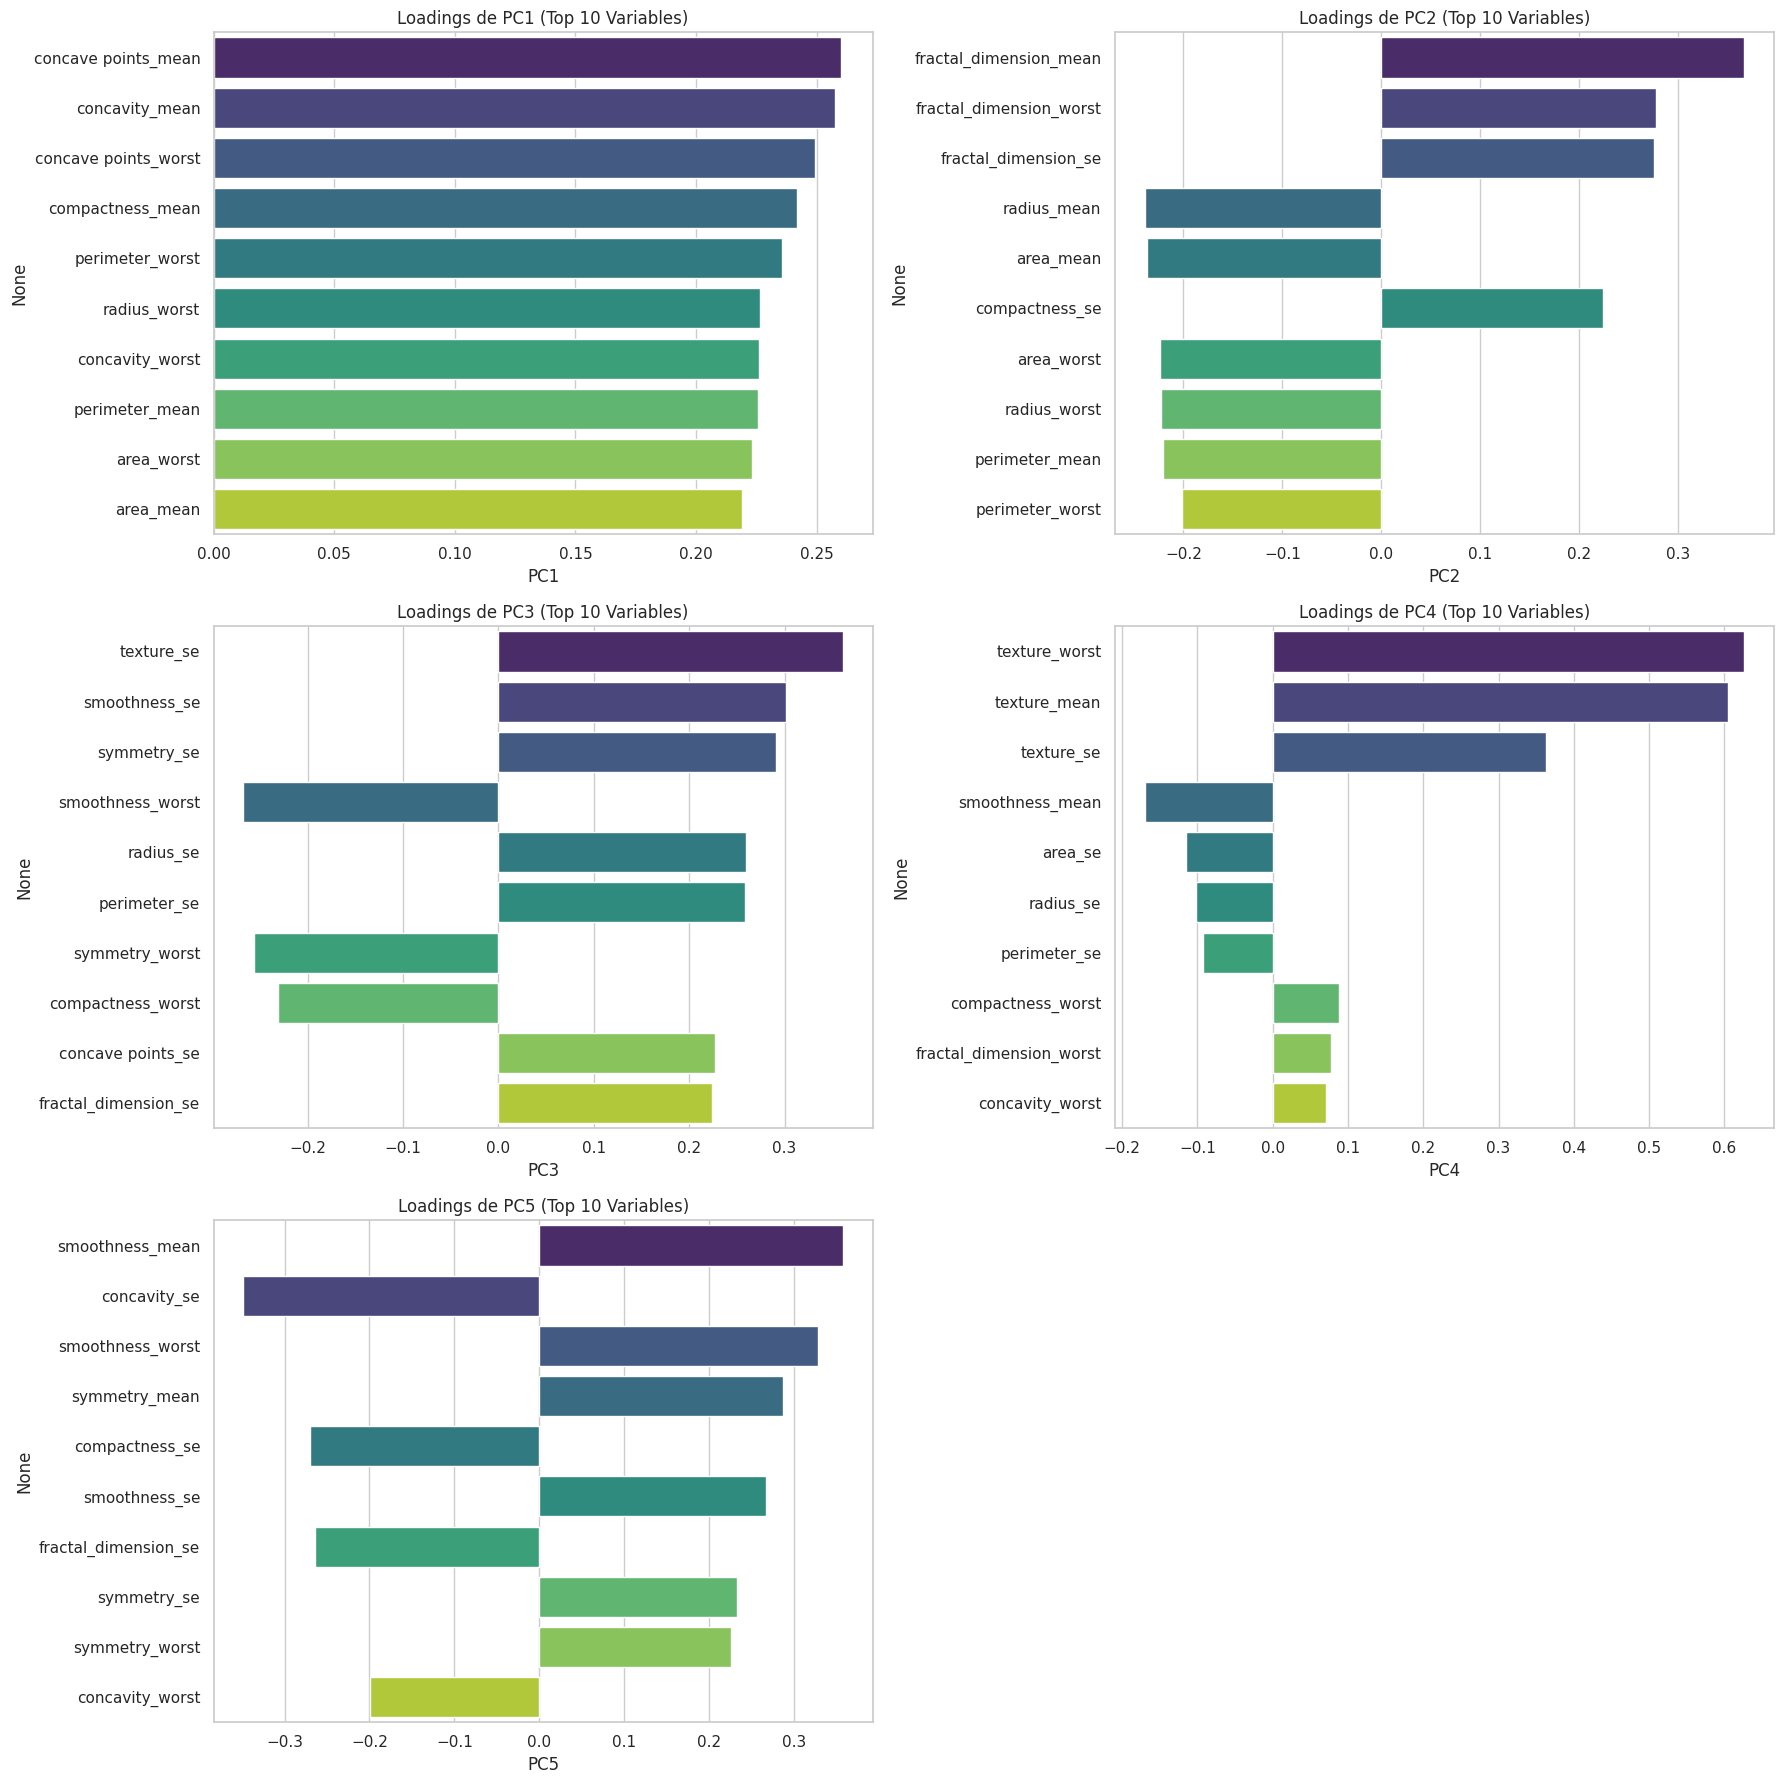

In [17]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=X.columns)

fig, axes = plt.subplots(3, 2, figsize=(18, 18)) # Create 3 rows, 2 columns for 5 plots + 1 empty
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i in range(5):
    pc_name = f'PC{i+1}'
    top_pc_loadings = loadings[pc_name].abs().sort_values(ascending=False).head(10).index
    sns.barplot(x=loadings.loc[top_pc_loadings, pc_name], y=top_pc_loadings, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Loadings de {pc_name} (Top 10 Variables)')

# Hide the unused 6th subplot if there are only 5 components
if len(axes) > 5:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### 1.2 Biplot
Proyectamos observaciones y variables en el espacio de PC1 vs PC2.

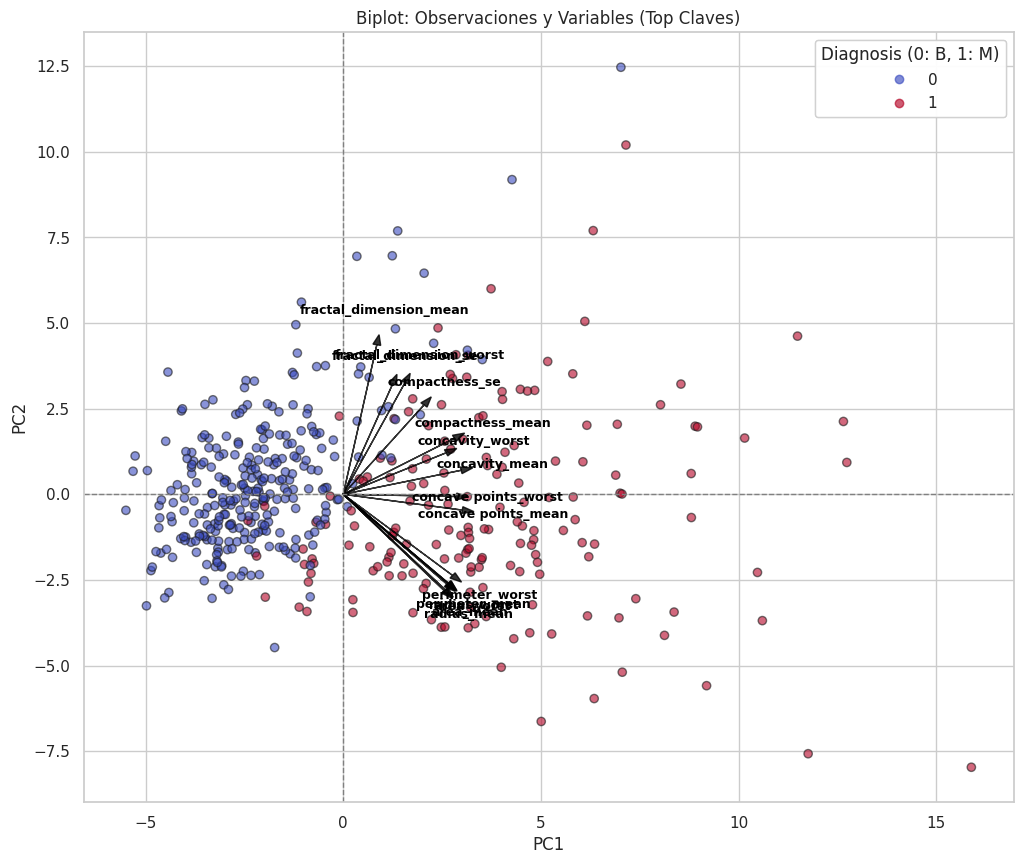

In [8]:
def biplot(score, coeff, labels=None):
    fig, ax = plt.subplots(figsize=(12, 10))

    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    scatter = ax.scatter(xs, ys, c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
    legend = ax.legend(*scatter.legend_elements(), title="Diagnosis (0: B, 1: M)")
    ax.add_artist(legend)

    arrow_multiplier = max(xs.max(), ys.max()) * 0.8

    for i in range(n):
        ax.arrow(0, 0, coeff[i, 0] * arrow_multiplier, coeff[i, 1] * arrow_multiplier,
                 color='black', alpha=0.8, head_width=0.2, length_includes_head=True)
        if labels is not None:
            ax.text(coeff[i, 0] * arrow_multiplier * 1.15, coeff[i, 1] * arrow_multiplier * 1.15,
                    labels[i], color='black', ha='center', va='center', fontsize=9, fontweight='bold')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot: Observaciones y Variables (Top Claves)")
    plt.grid(True)
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.show()

top_vars = list(set(top_pc1).union(set(top_pc2)))
coeff_subset = pca.components_.T[X.columns.get_indexer(top_vars)]
biplot(X_train_pca, coeff_subset, labels=top_vars)

### 1.3 Scree Plot
Graficamos la varianza explicada por cada una de las 5 componentes y su varianza acumulada.

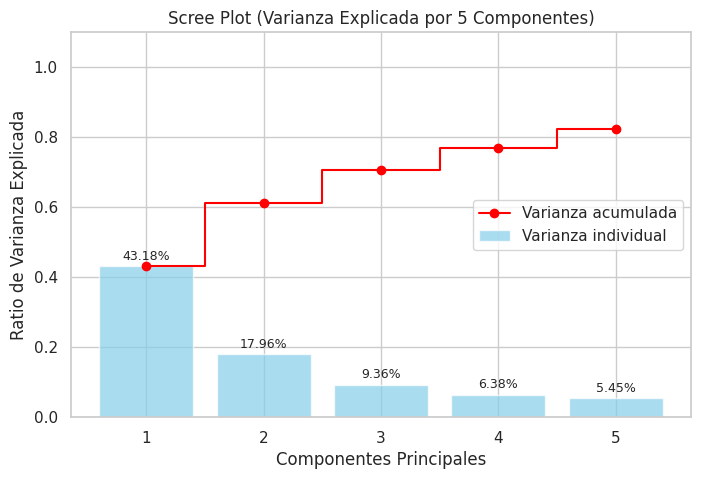

In [9]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
bars = plt.bar(range(1, 6), explained_variance, alpha=0.7, align='center', label='Varianza individual', color='skyblue')
plt.step(range(1, 6), cumulative_variance, where='mid', label='Varianza acumulada', color='red', marker='o')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontsize=9)

plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks(range(1, 6))
plt.title('Scree Plot (Varianza Explicada por 5 Componentes)')
plt.legend(loc='center right')
plt.ylim(0, 1.1)
plt.show()

---
## 2. Evaluación de Rendimiento

### 2.1 Comparación: Variables Escaladas vs Sin Escalar
Primero, probamos por qué KNN requiere datos escalados utilizando un K=5 como referencia.

In [10]:
# KNN sin escalar los datos
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

# KNN con datos escalados
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print("--- Impacto del Escalado en KNN (K=5) ---")
print(f"Accuracy SIN escalar: {acc_unscaled:.4f}")
print(f"Accuracy CON escalado: {acc_scaled:.4f}")
print("\nDe aquí en adelante utilizamos únicamente datos ESCALADOS.")

--- Impacto del Escalado en KNN (K=5) ---
Accuracy SIN escalar: 0.7544
Accuracy CON escalado: 0.9561

De aquí en adelante utilizamos únicamente datos ESCALADOS.


### 2.2 Métricas de Rendimiento (Sin PCA vs Con PCA 5 Comp)
Calculamos `Accuracy`, `Precision`, `Recall` y `F1-Score` para valores de K del 1 al 20.

In [11]:
k_values = range(1, 21)
metrics = {'K': [], 'Metrica': [], 'Valor': [], 'Modelo': []}

for k in k_values:
    # --- Modelo Sin PCA (Escalado) ---
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    metrics['K'].extend([k]*4)
    metrics['Modelo'].extend(['Sin PCA']*4)
    metrics['Metrica'].extend(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    metrics['Valor'].extend([
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

    # --- Modelo Con PCA (5 componentes) ---
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train)
    y_pred_pca = knn_pca.predict(X_test_pca)

    metrics['K'].extend([k]*4)
    metrics['Modelo'].extend(['Con PCA (5 Comp)']*4)
    metrics['Metrica'].extend(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    metrics['Valor'].extend([
        accuracy_score(y_test, y_pred_pca),
        precision_score(y_test, y_pred_pca),
        recall_score(y_test, y_pred_pca),
        f1_score(y_test, y_pred_pca)
    ])

df_metrics = pd.DataFrame(metrics)

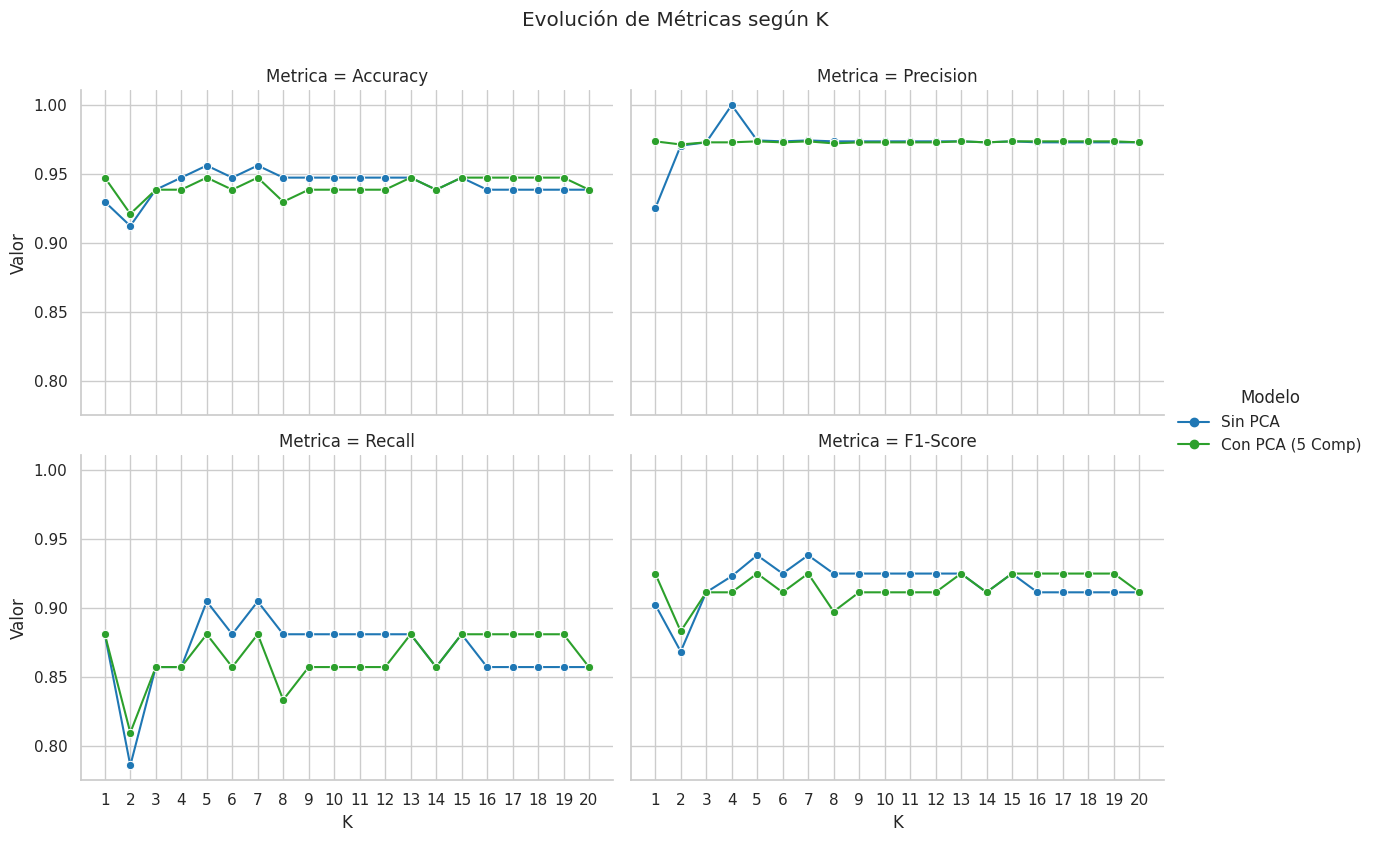

In [12]:
g = sns.relplot(
    data=df_metrics, x="K", y="Valor", hue="Modelo", col="Metrica",
    kind="line", marker="o", col_wrap=2, height=4, aspect=1.5, palette=['#1f77b4', '#2ca02c']
)
g.set(xticks=k_values)
g.fig.suptitle('Evolución de Métricas según K', y=1.05)
plt.show()

---
## 3. Matrices de Confusión
Comparamos los errores (falsos positivos/negativos) de ambos modelos para un $K=5$.

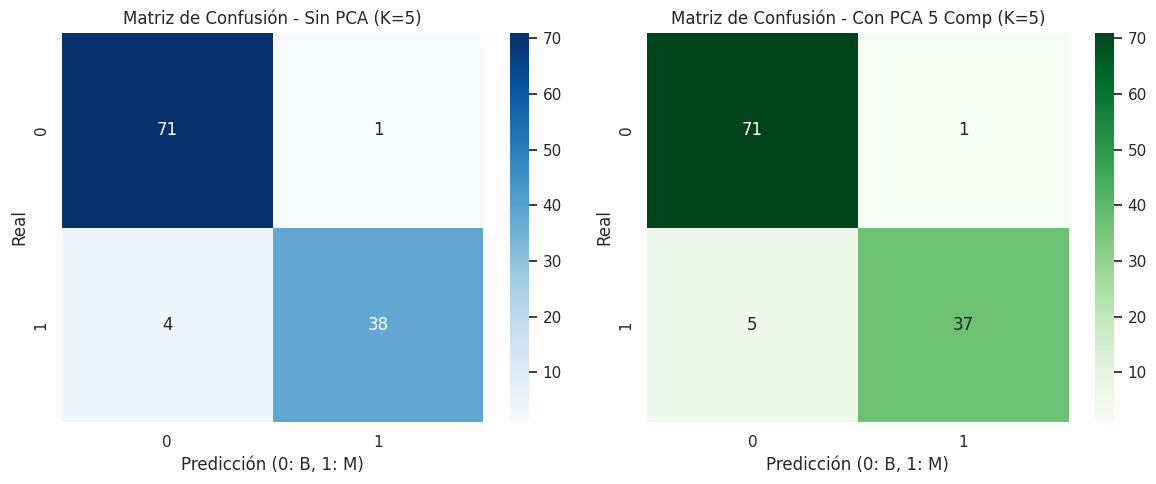

In [13]:
k_optimo = 5

knn_opt = KNeighborsClassifier(n_neighbors=k_optimo)
knn_opt.fit(X_train_scaled, y_train)
y_pred_opt = knn_opt.predict(X_test_scaled)

knn_pca_opt = KNeighborsClassifier(n_neighbors=k_optimo)
knn_pca_opt.fit(X_train_pca, y_train)
y_pred_pca_opt = knn_pca_opt.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusión - Sin PCA (K={k_optimo})')
axes[0].set_xlabel('Predicción (0: B, 1: M)')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_pca_opt), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Matriz de Confusión - Con PCA 5 Comp (K={k_optimo})')
axes[1].set_xlabel('Predicción (0: B, 1: M)')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()